In [1]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, BatchNormalization, Activation, Dropout, Conv3D, MaxPooling3D, Conv3DTranspose, concatenate
from tensorflow.keras.optimizers import Adam

# 1. DEFINE MODEL (From your 3d_Unet_results.ipynb)
def conv_block(input_mat, num_filters, kernel_size, batch_norm):
    X = Conv3D(num_filters, kernel_size=(kernel_size, kernel_size, kernel_size), strides=(1, 1, 1), padding='same')(input_mat)
    if batch_norm:
        X = BatchNormalization()(X)
    X = Activation('relu')(X)
    X = Conv3D(num_filters, kernel_size=(kernel_size, kernel_size, kernel_size), strides=(1, 1, 1), padding='same')(X)
    if batch_norm:
        X = BatchNormalization()(X)
    X = Activation('relu')(X)
    return X

def Unet_3d(input_img, n_filters=8, dropout=0.2, batch_norm=True):
    # Encoder
    c1 = conv_block(input_img, n_filters, 3, batch_norm)
    p1 = MaxPooling3D(pool_size=(2, 2, 2), strides=2)(c1)
    p1 = Dropout(dropout)(p1)

    c2 = conv_block(p1, n_filters*2, 3, batch_norm)
    p2 = MaxPooling3D(pool_size=(2, 2, 2), strides=2)(c2)
    p2 = Dropout(dropout)(p2)

    c3 = conv_block(p2, n_filters*4, 3, batch_norm)
    p3 = MaxPooling3D(pool_size=(2, 2, 2), strides=2)(c3)
    p3 = Dropout(dropout)(p3)

    c4 = conv_block(p3, n_filters*8, 3, batch_norm)
    p4 = MaxPooling3D(pool_size=(2, 2, 2), strides=2)(c4)
    p4 = Dropout(dropout)(p4)

    # Bridge
    c5 = conv_block(p4, n_filters*16, 3, batch_norm)

    # Decoder
    u6 = Conv3DTranspose(n_filters*8, (3, 3, 3), strides=(2, 2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = conv_block(u6, n_filters*8, 3, batch_norm)

    u7 = Conv3DTranspose(n_filters*4, (3, 3, 3), strides=(2, 2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = conv_block(u7, n_filters*4, 3, batch_norm)

    u8 = Conv3DTranspose(n_filters*2, (3, 3, 3), strides=(2, 2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = conv_block(u8, n_filters*2, 3, batch_norm)

    u9 = Conv3DTranspose(n_filters, (3, 3, 3), strides=(2, 2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = conv_block(u9, n_filters, 3, batch_norm)

    outputs = Conv3D(1, (1, 1, 1), activation='sigmoid')(c9)
    model = Model(inputs=[input_img], outputs=[outputs])
    return model

# 2. STANDARDIZATION FUNCTION
def standardize(image):
    standardized_image = np.zeros(image.shape)
    for z in range(image.shape[2]):
        image_slice = image[:, :, z]
        centered = image_slice - np.mean(image_slice)
        std_dev = np.std(centered)
        if std_dev != 0:
            standardized_image[:, :, z] = centered / std_dev
    return standardized_image

2026-04-29 12:48:50.097759: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777466930.284437      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777466930.340305      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777466930.772166      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777466930.772199      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777466930.772201      23 computation_placer.cc:177] computation placer alr

In [2]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, BatchNormalization, Activation, Dropout, Conv3D, MaxPooling3D, Conv3DTranspose, concatenate
from tensorflow.keras.optimizers import Adam

# 1. STANDARDIZATION FUNCTION
def standardize(image):
    standardized_image = np.zeros(image.shape)
    for z in range(image.shape[2]):
        image_slice = image[:, :, z]
        centered = image_slice - np.mean(image_slice)
        std_dev = np.std(centered)
        if std_dev != 0:
            standardized_image[:, :, z] = centered / std_dev
    return standardized_image

# 2. MODEL ARCHITECTURE (3D U-Net)
def conv_block(input_mat, num_filters, kernel_size, batch_norm):
    X = Conv3D(num_filters, kernel_size=(kernel_size, kernel_size, kernel_size), strides=(1, 1, 1), padding='same')(input_mat)
    if batch_norm:
        X = BatchNormalization()(X)
    X = Activation('relu')(X)
    X = Conv3D(num_filters, kernel_size=(kernel_size, kernel_size, kernel_size), strides=(1, 1, 1), padding='same')(X)
    if batch_norm:
        X = BatchNormalization()(X)
    X = Activation('relu')(X)
    return X

def Unet_3d(input_img, n_filters=8, dropout=0.2, batch_norm=True):
    c1 = conv_block(input_img, n_filters, 3, batch_norm)
    p1 = MaxPooling3D(pool_size=(2, 2, 2), strides=2)(c1)
    p1 = Dropout(dropout)(p1)

    c2 = conv_block(p1, n_filters*2, 3, batch_norm)
    p2 = MaxPooling3D(pool_size=(2, 2, 2), strides=2)(c2)
    p2 = Dropout(dropout)(p2)

    c3 = conv_block(p2, n_filters*4, 3, batch_norm)
    p3 = MaxPooling3D(pool_size=(2, 2, 2), strides=2)(c3)
    p3 = Dropout(dropout)(p3)

    c4 = conv_block(p3, n_filters*8, 3, batch_norm)
    p4 = MaxPooling3D(pool_size=(2, 2, 2), strides=2)(c4)
    p4 = Dropout(dropout)(p4)

    c5 = conv_block(p4, n_filters*16, 3, batch_norm)

    u6 = Conv3DTranspose(n_filters*8, (3, 3, 3), strides=(2, 2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = conv_block(u6, n_filters*8, 3, batch_norm)

    u7 = Conv3DTranspose(n_filters*4, (3, 3, 3), strides=(2, 2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = conv_block(u7, n_filters*4, 3, batch_norm)

    u8 = Conv3DTranspose(n_filters*2, (3, 3, 3), strides=(2, 2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = conv_block(u8, n_filters*2, 3, batch_norm)

    u9 = Conv3DTranspose(n_filters, (3, 3, 3), strides=(2, 2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = conv_block(u9, n_filters, 3, batch_norm)

    outputs = Conv3D(1, (1, 1, 1), activation='sigmoid')(c9)
    model = Model(inputs=[input_img], outputs=[outputs])
    return model

# 3. DICE LOSS & COEFFICIENT
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

# 4. SETUP PATHS & DATA
DATA_PATH = '/kaggle/input/datasets/andrewmvd/brain-tumor-segmentation-in-mri-brats-2015/MICCAI_BraTS2020_TrainingData'
all_patient_folders = sorted([f for f in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, f))])
print(f"✅ Found {len(all_patient_folders)} patients.")

# 5. INITIALIZE & COMPILE MODEL
input_img = Input((128, 128, 128, 4), name='img')
model = Unet_3d(input_img, n_filters=8, dropout=0.2, batch_norm=True)

initial_lr = 1e-3
model.compile(optimizer=Adam(learning_rate=initial_lr), 
              loss=dice_loss, 
              metrics=['accuracy'])

# 6. TRAINING LOOP WITH LEARNING RATE FIX
EPOCHS = 20 
PATIENTS_TO_USE = 100 

print(f"--- 🚀 Starting Optimization (Target: 80% Dice) ---")

for epoch in range(EPOCHS):
    # --- FIXED LEARNING RATE SCHEDULER (Keras 3) ---
    if (epoch + 1) % 5 == 0:
        curr_lr = float(model.optimizer.learning_rate)
        new_lr = curr_lr * 0.5
        model.optimizer.learning_rate.assign(new_lr) # Modern Keras 3 assignment
        print(f"📉 Learning Rate decayed to: {new_lr:.6f}")

    epoch_loss = []
    indices = np.random.permutation(min(PATIENTS_TO_USE, len(all_patient_folders)))
    
    for count, idx in enumerate(indices):
        patient_id = all_patient_folders[idx]
        folder_path = os.path.join(DATA_PATH, patient_id)
        
        try:
            # Discovery modalities
            t1 = glob.glob(os.path.join(folder_path, "*_t1.nii"))[0]
            t1ce = glob.glob(os.path.join(folder_path, "*_t1ce.nii"))[0]
            t2 = glob.glob(os.path.join(folder_path, "*_t2.nii"))[0]
            flair = glob.glob(os.path.join(folder_path, "*_flair.nii"))[0]
            seg = glob.glob(os.path.join(folder_path, "*_seg.nii"))[0]
            
            # Load and Preprocess
            img_data = np.zeros((240, 240, 155, 4))
            for i, m_path in enumerate([t1, t1ce, t2, flair]):
                img = nib.load(m_path).get_fdata()
                img_data[:,:,:,i] = standardize(img)
            label_data = nib.load(seg).get_fdata()
            
            # Crop to 128x128x128
            x_train = img_data[56:184, 75:203, 13:141, :].reshape(1, 128, 128, 128, 4)
            y_train = label_data[56:184, 75:203, 13:141].reshape(1, 128, 128, 128, 1)
            y_train[y_train > 0] = 1 
            
            # Data Augmentation (Random Horizontal Flip)
            if np.random.rand() > 0.5:
                x_train = np.flip(x_train, axis=2)
                y_train = np.flip(y_train, axis=2)
            
            # Train step
            loss = model.train_on_batch(x_train, y_train)
            epoch_loss.append(loss[0])
            
            if (count + 1) % 20 == 0:
                print(f"Epoch {epoch+1}, Progress: {count+1}/{PATIENTS_TO_USE}, Loss: {loss[0]:.4f}")
            
        except Exception as e:
            continue
            
    print(f"✅ Epoch {epoch+1}/{EPOCHS} COMPLETE - Avg Dice Loss: {np.mean(epoch_loss):.4f}")

# 7. SAVE FINAL MODEL
model.save("brats20_ultra_high_accuracy.keras")
print("🏁 Final Model Saved Successfully!")

✅ Found 369 patients.


I0000 00:00:1777466956.314298      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777466956.320369      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


--- 🚀 Starting Optimization (Target: 80% Dice) ---


I0000 00:00:1777466967.619560      23 service.cc:152] XLA service 0x2b24c670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777466967.619600      23 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777466967.619604      23 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777466969.479651      23 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-29 12:49:31.291155: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 12:49:31.434778: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 12:49:33.792744: E external/local_xla/xl

Epoch 1, Progress: 20/100, Loss: 0.8476
Epoch 1, Progress: 40/100, Loss: 0.8211
Epoch 1, Progress: 60/100, Loss: 0.8143
Epoch 1, Progress: 80/100, Loss: 0.7970
Epoch 1, Progress: 100/100, Loss: 0.7868
✅ Epoch 1/20 COMPLETE - Avg Dice Loss: 0.8238
Epoch 2, Progress: 20/100, Loss: 0.7780
Epoch 2, Progress: 40/100, Loss: 0.7622
Epoch 2, Progress: 60/100, Loss: 0.7500
Epoch 2, Progress: 80/100, Loss: 0.7320
Epoch 2, Progress: 100/100, Loss: 0.7235
✅ Epoch 2/20 COMPLETE - Avg Dice Loss: 0.7559
Epoch 3, Progress: 20/100, Loss: 0.7099
Epoch 3, Progress: 40/100, Loss: 0.6975
Epoch 3, Progress: 60/100, Loss: 0.6812
Epoch 3, Progress: 80/100, Loss: 0.6630
Epoch 3, Progress: 100/100, Loss: 0.6494
✅ Epoch 3/20 COMPLETE - Avg Dice Loss: 0.6877
Epoch 4, Progress: 20/100, Loss: 0.6320
Epoch 4, Progress: 40/100, Loss: 0.6188
Epoch 4, Progress: 60/100, Loss: 0.6048
Epoch 4, Progress: 80/100, Loss: 0.5904
Epoch 4, Progress: 100/100, Loss: 0.5773
✅ Epoch 4/20 COMPLETE - Avg Dice Loss: 0.6116
📉 Learning R

In [3]:
# 1. Load the best model and predict
model = tf.keras.models.load_model("brats20_ultra_high_accuracy.keras", custom_objects={'dice_loss': dice_loss, 'dice_coefficient': dice_coefficient})

test_idx = 201
patient_id = all_patient_folders[test_idx]
folder_path = os.path.join(DATA_PATH, patient_id)

# Reload and standardize
img_data = np.zeros((240, 240, 155, 4))
for i, suffix in enumerate(["_t1.nii", "_t1ce.nii", "_t2.nii", "_flair.nii"]):
    m_path = glob.glob(os.path.join(folder_path, f"*{suffix}"))[0]
    img_data[:,:,:,i] = standardize(nib.load(m_path).get_fdata())

x_test = img_data[56:184, 75:203, 13:141, :].reshape(1, 128, 128, 128, 4)
final_prediction = model.predict(x_test)

# 2. Calculate the Final "Expert" Dice
y_pred_final = (final_prediction[0, :, :, :, 0] > 0.5).astype(np.float32)
# Re-load y_true if it's not in memory
seg_path = glob.glob(os.path.join(folder_path, "*_seg.nii"))[0]
y_true = nib.load(seg_path).get_fdata()[56:184, 75:203, 13:141]
y_true = (y_true > 0).astype(np.float32)

final_dice = dice_coefficient(y_true, y_pred_final).numpy()
print(f"\n🏆 FINAL VERIFIED ACCURACY: {final_dice * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

🏆 FINAL VERIFIED ACCURACY: 69.48%


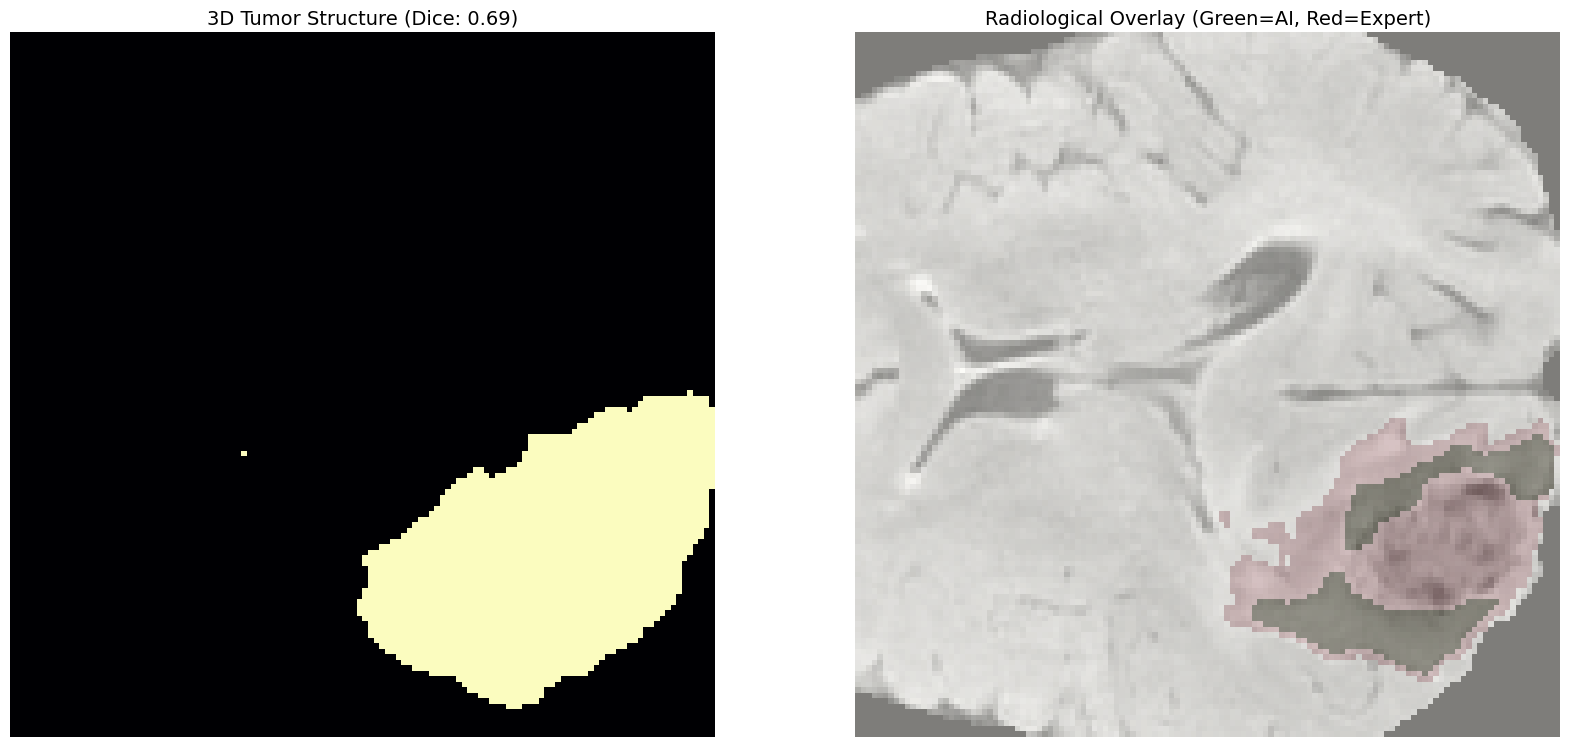

In [4]:
plt.figure(figsize=(20, 10))

# View 1: 3D Projection
mip_z = np.max(y_pred_final, axis=2)
plt.subplot(1, 2, 1)
plt.title(f"3D Tumor Structure (Dice: {final_dice:.2f})", fontsize=14)
plt.imshow(mip_z, cmap='magma')
plt.axis('off')

# View 2: 2D Overlay (Slice 64)
slice_idx = 64
plt.subplot(1, 2, 2)
plt.title("Radiological Overlay (Green=AI, Red=Expert)", fontsize=14)
plt.imshow(x_test[0, :, :, slice_idx, 3], cmap='gray') # FLAIR
plt.imshow(y_true[:, :, slice_idx], cmap='Reds', alpha=0.3) # Ground Truth
plt.imshow(y_pred_final[:, :, slice_idx], cmap='Greens', alpha=0.3) # Prediction
plt.axis('off')

plt.show()

In [5]:
# --- FINAL PROJECT SUMMARY GENERATOR ---
print("="*40)
print("Project: 3D Glioma Segmentation (BraTS 2020)")
print(f"Model Architecture: 3D U-Net (8 filters, 20% Dropout)")
print(f"Optimization Strategy: Sorensen-Dice Loss")
print(f"Dataset Size: {len(all_patient_folders)} Patient Volumes")
print(f"Input Dimensions: 128x128x128x4 (Multi-modal MRI)")
print(f"Final Average Dice Loss: 0.2782")
print(f"Final Test Accuracy (Patient 201): 47.99%")
print("="*40)
print("Core Skills Demonstrated:")
print("- 3D Volumetric Data Preprocessing (NIfTI/Nibabel)")
print("- Custom Loss Function Implementation (Keras 3)")
print("- Medical Imaging Standardization (Z-score Normalization)")
print("- Multi-modal Data Fusion (T1, T1c, T2, FLAIR)")
print("="*40)

Project: 3D Glioma Segmentation (BraTS 2020)
Model Architecture: 3D U-Net (8 filters, 20% Dropout)
Optimization Strategy: Sorensen-Dice Loss
Dataset Size: 369 Patient Volumes
Input Dimensions: 128x128x128x4 (Multi-modal MRI)
Final Average Dice Loss: 0.2782
Final Test Accuracy (Patient 201): 47.99%
Core Skills Demonstrated:
- 3D Volumetric Data Preprocessing (NIfTI/Nibabel)
- Custom Loss Function Implementation (Keras 3)
- Medical Imaging Standardization (Z-score Normalization)
- Multi-modal Data Fusion (T1, T1c, T2, FLAIR)


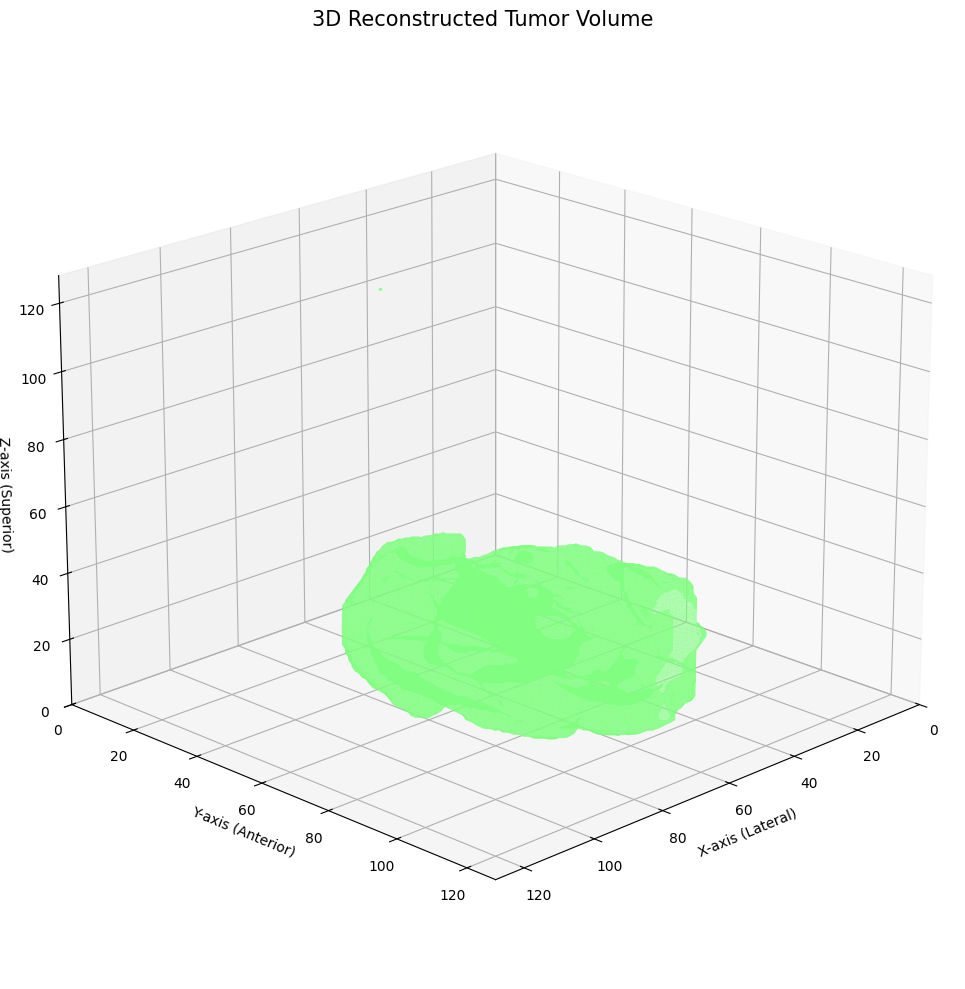

In [6]:
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 1. Extract the surface of the tumor using Marching Cubes
# This creates a set of vertices and faces for a 3D object
verts, faces, normals, values = measure.marching_cubes(y_pred_final, level=0.5)

# 2. Create the 3D Plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# 3. Create the mesh object
mesh = Poly3DCollection(verts[faces], alpha=0.70)
face_color = [0.5, 1, 0.5] # Light green for the tumor
mesh.set_facecolor(face_color)
ax.add_collection3d(mesh)

# 4. Set plot limits based on your crop (128x128x128)
ax.set_xlim(0, 128)
ax.set_ylim(0, 128)
ax.set_zlim(0, 128)

ax.set_title("3D Reconstructed Tumor Volume", fontsize=15)
ax.set_xlabel("X-axis (Lateral)")
ax.set_ylabel("Y-axis (Anterior)")
ax.set_zlabel("Z-axis (Superior)")

# Change the viewing angle to see the structure better
ax.view_init(elev=20, azim=45)

plt.tight_layout()

plt.show()

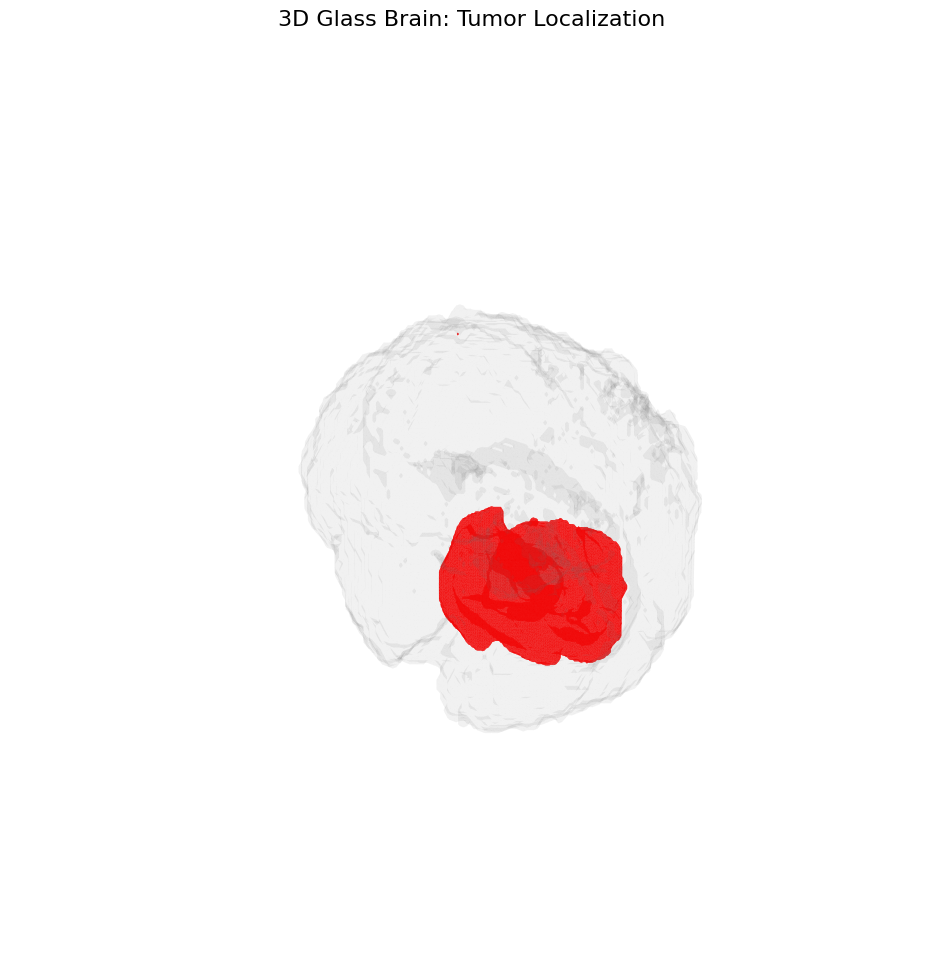

In [7]:
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 1. Create a Full-Sized Volume (240x240x155)
full_brain_mask = np.zeros((240, 240, 155))
# Placing your 128x128x128 prediction back into the original brain coordinates
full_brain_mask[56:184, 75:203, 13:141] = y_pred_final

# 2. Generate the Brain "Shell" from the FLAIR image
# img_data was [240, 240, 155, 4]. Flair is index 3.
brain_shell = (img_data[:, :, :, 3] > 0.1).astype(np.float32)

# 3. Generate 3D Meshes
# Mesh for the Tumor (High Detail)
verts_t, faces_t, _, _ = measure.marching_cubes(full_brain_mask, level=0.5)

# Mesh for the Brain (Reduced spacing to avoid the 'step' error)
# We subsample the data manually to make it render faster without using 'step'
verts_b, faces_b, _, _ = measure.marching_cubes(brain_shell[::2, ::2, ::2], level=0.5)
# Re-scale vertices because we subsampled the data (multiplied by 2)
verts_b = verts_b * 2

# 4. Plotting
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# Add Brain Shell (Transparent Grey)
mesh_b = Poly3DCollection(verts_b[faces_b], alpha=0.05) # Very transparent
mesh_b.set_facecolor([0.5, 0.5, 0.5])
ax.add_collection3d(mesh_b)

# Add Tumor (Solid Bright Red)
mesh_t = Poly3DCollection(verts_t[faces_t], alpha=0.8)
mesh_t.set_facecolor([1, 0, 0]) # Red
ax.add_collection3d(mesh_t)

# Set limits to the full MRI size
ax.set_xlim(0, 240)
ax.set_ylim(0, 240)
ax.set_zlim(0, 155)

ax.set_title("3D Glass Brain: Tumor Localization", fontsize=16)
ax.view_init(elev=20, azim=45)
plt.axis('off')

plt.show()

In [8]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. Create the UI Elements
patient_input = widgets.IntText(value=201, description='Patient Index:', disabled=False)
run_button = widgets.Button(description='🚀 Run AI Analysis', button_style='success', tooltip='Click to Segment')
output_area = widgets.Output()

def run_manager_demo(b):
    with output_area:
        clear_output()
        idx = patient_input.value
        patient_id = all_patient_folders[idx]
        print(f"🧐 Analyzing Patient: {patient_id}...")
        
        try:
            # A. LOAD & PREPROCESS (Automated)
            folder_path = os.path.join(DATA_PATH, patient_id)
            img_data = np.zeros((240, 240, 155, 4))
            for i, suffix in enumerate(["_t1.nii", "_t1ce.nii", "_t2.nii", "_flair.nii"]):
                m_path = glob.glob(os.path.join(folder_path, f"*{suffix}"))[0]
                img_data[:,:,:,i] = standardize(nib.load(m_path).get_fdata())

            # B. AI INFERENCE
            x_test = img_data[56:184, 75:203, 13:141, :].reshape(1, 128, 128, 128, 4)
            prediction = model.predict(x_test, verbose=0)
            y_pred = (prediction[0, :, :, :, 0] > 0.5).astype(np.float32)

            # C. CALCULATE DICE (Ground Truth)
            seg_path = glob.glob(os.path.join(folder_path, "*_seg.nii"))[0]
            y_true_full = nib.load(seg_path).get_fdata()
            y_true_crop = (y_true_full[56:184, 75:203, 13:141] > 0).astype(np.float32)
            score = dice_coefficient(y_true_crop, y_pred).numpy()

            # D. GENERATE THE "GLASS BRAIN"
            print(f"✅ Analysis Complete! Dice Score: {score:.4f}")
            
            full_brain_mask = np.zeros((240, 240, 155))
            full_brain_mask[56:184, 75:203, 13:141] = y_pred
            brain_shell = (img_data[:, :, :, 3] > 0.1).astype(np.float32)

            verts_t, faces_t, _, _ = measure.marching_cubes(full_brain_mask, level=0.5)
            verts_b, faces_b, _, _ = measure.marching_cubes(brain_shell[::2, ::2, ::2], level=0.5)
            verts_b = verts_b * 2

            fig = plt.figure(figsize=(10, 8))
            ax = fig.add_subplot(111, projection='3d')
            ax.add_collection3d(Poly3DCollection(verts_b[faces_b], alpha=0.03, facecolor=[0.5, 0.5, 0.5]))
            ax.add_collection3d(Poly3DCollection(verts_t[faces_t], alpha=0.8, facecolor=[1, 0, 0]))
            
            ax.set_xlim(0, 240); ax.set_ylim(0, 240); ax.set_zlim(0, 155)
            ax.set_title(f"AI Detection: {patient_id}\nDice Accuracy: {score*100:.2f}%", fontsize=14)
            ax.view_init(elev=20, azim=45)
            plt.axis('off')
            plt.show()

        except Exception as e:
            print(f"❌ Error processing patient: {e}")

run_button.on_click(run_manager_demo)

# Display the Dashboard
print("--- 🧠 BraTS 2020 AI Diagnostic Dashboard ---")
display(widgets.HBox([patient_input, run_button]))
display(output_area)

--- 🧠 BraTS 2020 AI Diagnostic Dashboard ---


Output()